# Time Series Forecasting

files needed = none

We continue to learn about the `statsmodels` package, which provides functions for formulating and estimating statistical models. In this notebook, we focus on time series analysis and forecasting.

## FRED Unemployment Data

We'll use FRED unemployment data to reproduce a few time series analyses in Blanchard and Katz's [Regional Evolutions (1992)](https://scholar.harvard.edu/files/lkatz/files/regional_evolutions.pdf). This will be a nice way to introduce basic time series forecasting and use our tools to answer a policy question of considerable interest: How do state-specific economic shocks affect state economies in the short-run and in the long-run?

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import statsmodels.formula.api as smf
import pandas_datareader.data as web  
import os
os.chdir('/Users/jackson/Documents/ECON570')
# New today: time series analysis
import statsmodels.tsa.api as tsa

First, let's use pandas_datareader to bring in state unemployment data. We'll bring in unemployment rates for the 51 states (including DC) and the national unemployment rate.

In [3]:
# These codes are for the unemployment rates in each of the 51 states
# and the national unemploymnent rate.
codes = ['ALUR', 'AKUR', 'AZUR', 'ARUR', 'CAUR', 'COUR', 'CTUR',
         'DEUR', 'DCUR', 'FLUR', 'GAUR', 'HIUR', 'IDUR', 'ILUR',
         'INUR', 'IAUR', 'KSUR', 'KYUR', 'LAUR', 'MEUR', 'MDUR',
         'MAUR', 'MIUR', 'MNUR', 'MSUR', 'MOUR', 'MTUR', 'NEUR',
         'NVUR', 'NHUR', 'NJUR', 'NMUR', 'NYUR', 'NCUR', 'NDUR',
         'OHUR', 'OKUR', 'ORUR', 'PAUR', 'RIUR', 'SCUR', 'SDUR',
         'TNUR', 'TXUR', 'UTUR', 'VTUR', 'VAUR', 'WAUR', 'WVUR',
         'WIUR', 'WYUR', 'UNRATE']

unemp = web.DataReader(codes, 'fred', start='1976-01-01', end='1990-12-01')
unemp.head(2)

,ALUR,AKUR,AZUR,ARUR,CAUR,COUR,CTUR,DEUR,DCUR,FLUR,...,TNUR,TXUR,UTUR,VTUR,VAUR,WAUR,WVUR,WIUR,WYUR,UNRATE
DATE,,,,,,,,,,,,,,,,,,,,,
1976-01-01,6.7,7.1,10.2,7.3,9.2,5.8,9.7,8.0,8.8,9.6,...,6.0,5.8,5.8,8.5,6.0,8.5,7.4,5.8,4.1,7.9
1976-02-01,6.6,7.1,10.2,7.3,9.2,5.8,9.7,8.0,8.8,9.7,...,6.0,5.8,5.9,8.5,6.0,8.5,7.4,5.8,4.1,7.7


Nice and clean. DATE is the index, and it's already in datetime format. Let's clean up the column names and resample to the annual level.

In [4]:
# Clean up column names
unemp.columns = [x.replace('UR','') for x in unemp.columns]
# Resample  
unemp_annual = unemp.resample('YE').mean()
unemp_annual.head(2)

,AL,AK,AZ,AR,CA,CO,CT,DE,DC,FL,...,TN,TX,UT,VT,VA,WA,WV,WI,WY,UNRATE
DATE,,,,,,,,,,,,,,,,,,,,,
1976-12-31,6.691667,7.591667,9.775000,6.900,9.158333,5.908333,9.158333,8.716667,8.633333,9.250000,...,6.116667,5.841667,5.600000,8.233333,5.858333,8.758333,7.183333,5.550,3.900000,7.70
1977-12-31,7.125000,9.825000,8.416667,6.475,8.383333,6.358333,7.050000,8.150000,8.566667,8.266667,...,6.225000,5.433333,5.191667,6.983333,5.458333,8.375000,6.908333,5.075,3.316667,7.05


### Persistence in Unemployment Rates across US States

How do states with relatively low/moderate/high unemployment rates in 1976 fare a decade later, in 1986? Let's create columns for unemployment rates in each of those two years.

In [5]:
# Set up for Blanchard and Katz's Figure 3
f3 = unemp_annual.loc[['1976-12-31','1986-12-31']]
f3.index=f3.index.year.astype(str)
f3 = f3.transpose()
f3.drop('UNRATE', inplace=True)
f3.index.name='State'
f3.head()

DATE,1976,1986
State,,
AL,6.691667,9.533333
AK,7.591667,11.025000
AZ,9.775000,7.041667
AR,6.900000,8.541667
CA,9.158333,6.766667


Following Blanchard and Katz, we'll use a simple `sns.regplot` to examine the correlation between state unemployment rates in each of those two years.

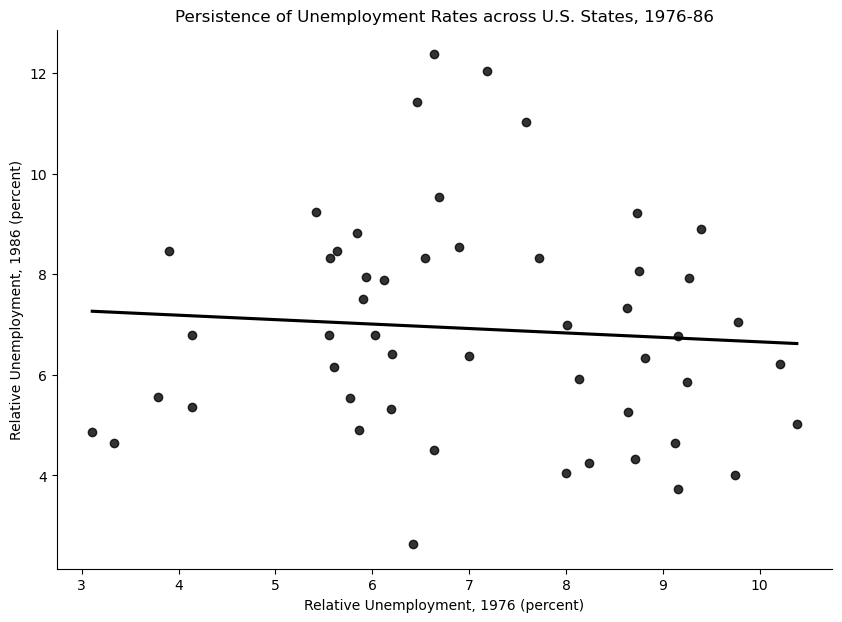

In [6]:
fig, ax = plt.subplots(figsize=(10,7)) 

sns.regplot(x='1976', y='1986', data=f3, ax = ax, color = 'black', ci = 0)

sns.despine(ax=ax)
ax.set_title('Persistence of Unemployment Rates across U.S. States, 1976-86')
ax.set(xlabel='Relative Unemployment, 1976 (percent)', ylabel='Relative Unemployment, 1986 (percent)')
plt.show()

The flat trend points to relatively low persistence in unemployment across these two years. States that had relatively high (low) employment in 1976 did not seem to have significantly higher (lower) employment in 1986.

Blanchard and Katz use state labels as markers. The simplest way that I found with matplotlib/seaborn is to create a regplot, suppress the automatic markers, and then use `.annotate()` to create a label for each point.

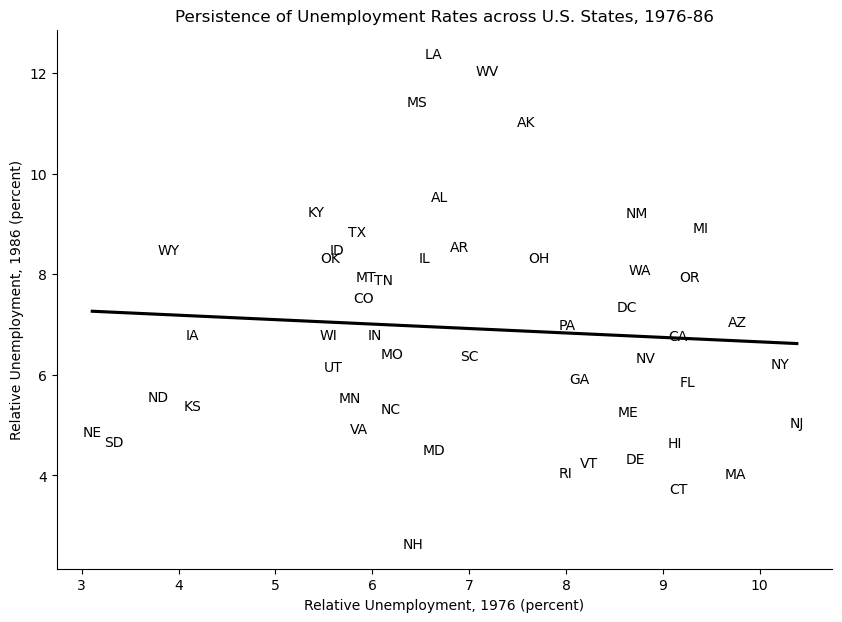

In [7]:
fig, ax = plt.subplots(figsize=(10,7)) 
# regplot fitted line without point markers
sns.regplot(x='1976', y='1986', data=f3, ax = ax, color = 'black', marker='', ci = 0) 

# annotate the state labels centered on the points
for x, y, label in zip(f3['1976'], f3['1986'], f3.index):
    ax.annotate(label, xy=(x,y), ha='center', va='center')

sns.despine(ax=ax)
ax.set_title('Persistence of Unemployment Rates across U.S. States, 1976-86')
ax.set(xlabel='Relative Unemployment, 1976 (percent)', ylabel='Relative Unemployment, 1986 (percent)')
plt.show()

Let's explore persistence in state relative unemployment further with some more formal analyses. 

### Constructing time series for each state

We are considering regional variations, relative to the country as a whole. In each year, let's calculate the difference between state and national unemployment rates.

In [8]:
# State unemployment rates, relative to the national average
unemp_annual = unemp_annual.apply(lambda x: x - unemp_annual['UNRATE'])
unemp_annual.drop(columns=['UNRATE'], inplace=True)
unemp_annual.head(2)

,AL,AK,AZ,AR,CA,CO,CT,DE,DC,FL,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
DATE,,,,,,,,,,,,,,,,,,,,,
1976-12-31,-1.008333,-0.108333,2.075000,-0.800,1.458333,-1.791667,1.458333,1.016667,0.933333,1.550000,...,-4.366667,-1.583333,-1.858333,-2.100000,0.533333,-1.841667,1.058333,-0.516667,-2.150,-3.800000
1977-12-31,0.075000,2.775000,1.366667,-0.575,1.333333,-0.691667,0.000000,1.100000,1.516667,1.216667,...,-3.666667,-0.825000,-1.616667,-1.858333,-0.066667,-1.591667,1.325000,-0.141667,-1.975,-3.733333


Let's stack the data so there's one row for each state-year combination.

In [9]:
unemp_s = unemp_annual.stack().to_frame()
unemp_s.reset_index(inplace=True)
unemp_s.head(2)

,DATE,level_1,0
0,1976-12-31,AL,-1.008333
1,1976-12-31,AK,-0.108333


Clean up the variable names and set a MultiIndex: 'state' then 'DATE' and sort by the MultiIndex.

In [10]:
unemp_s.rename(columns={'level_1':'state',0:'unemp'}, inplace=True)
unemp_s.set_index(['state','DATE'], inplace=True)
unemp_s.sort_index(inplace=True)
unemp_s.head()

unemp
state DATE                
AK    1976-12-31 -0.108333
      1977-12-31  2.775000
      1978-12-31  4.541667
      1979-12-31  3.200000
      1980-12-31  2.366667

Looking good.

## Time Series Stationarity

Now we have 51 different time series, and we want to understand generally how state-specific unemployment rates evolve over time.

Let's check out New York.

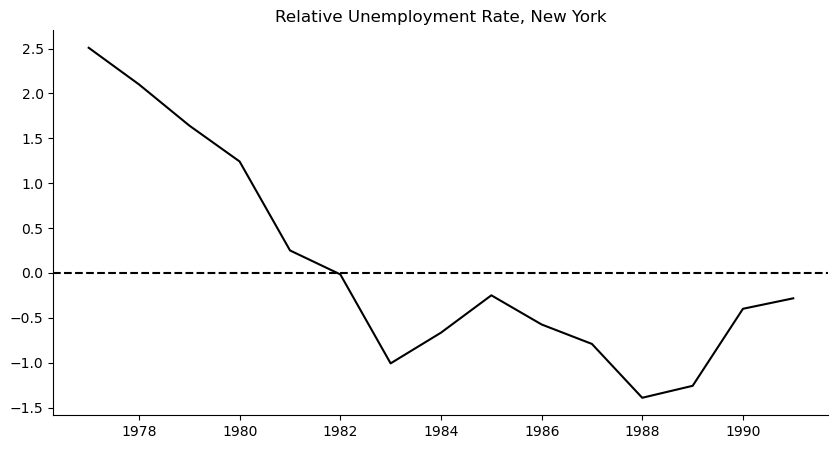

In [11]:
# Plot New York
fig, ax = plt.subplots(figsize=(10,5)) 
ax.plot(unemp_s.loc['NY'].index, unemp_s.loc['NY','unemp'], color='black') 
plt.axhline(y=0, color='black', linestyle='--')
ax.set_title('Relative Unemployment Rate, New York')
sns.despine(ax=ax)

Looks like New York was doing poorly (relative to the country) in the late 70s. Then, unemployment decreased significantly in the early 80s and hovered below the national average thereafter.

It does seem that after a large (or small) shock (positive or negative), the time series tends to move back toward the national average.

What about Arkansas?

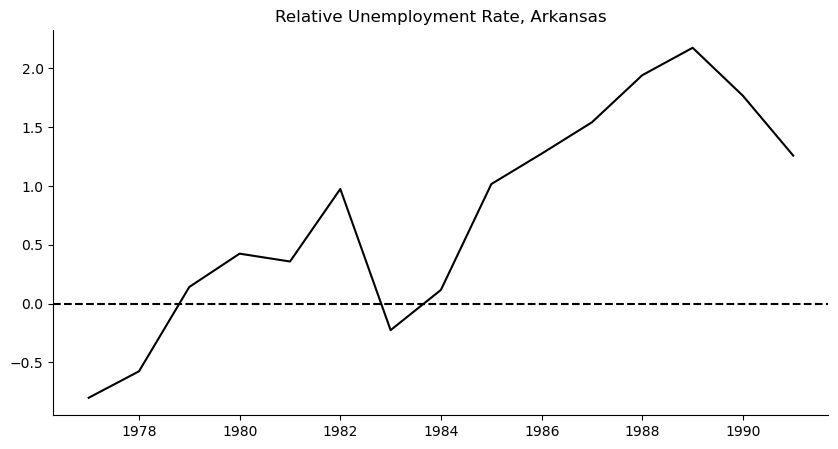

In [12]:
# Plot Arkansas
fig, ax = plt.subplots(figsize=(10,5)) 
ax.plot(unemp_s.loc['AR'].index, unemp_s.loc['AR','unemp'], color='black') 
plt.axhline(y=0, color='black', linestyle='--')
ax.set_title('Relative Unemployment Rate, Arkansas')
sns.despine(ax=ax)

The story looks very different in Arkansas. There was a significant increase in unemployment in the late 80s, when New York was doing relatively well. However, both time series (NY and AR) seem to converge back toward their initial unemployment rate after a big negative or positive shock.

Let's test for [*stationarity*](https://en.wikipedia.org/wiki/Stationary_process) in each of our 51 time series using an **(Augmented) Dickey-Fuller test**, only one of many possible tests. The null hypothesis of the Augmented Dickey-Fuller test is non-stationarity in the time series. It is essentially an OLS of period-over-period differences in the series on the lagged level of the series, as well as lagged differences.

I'll leave some of the details for your econometrics course, but I'll show you how to use python to run the test for each state.

We'll use a statsmodels package `tsa.adfuller()` to run the test and record the p-value for each state. A p-value less than 0.05 rejects the null hypothesis of non-stationarity at the 95% level.

In [13]:
# List of state abbreviations
states = unemp_s.index.get_level_values(0).unique().tolist()

In [14]:
# Augmented Dickey-Fuller test for stationarity, store p-value
def dickey_fuller(series):
    #X = series
    result = tsa.adfuller(series, regression='c', maxlag=2, autolag=None)
    return result[1]

# Run test for every state. Store p-vals in a list
pvals = [dickey_fuller(unemp_s.loc[state]) for state in states]

# Convert to a DataFrame
pvals_df = pd.DataFrame(zip(states, pvals), columns=['state', 'pval'])
pvals_df.head(5)

,state,pval
0,AK,0.082111
1,AL,0.189026
2,AR,0.692307
3,AZ,0.250349
4,CA,0.002151


In [15]:
pvals_df[pvals_df['pval'] < 0.05]

,state,pval
4,CA,0.002151
11,HI,0.012206
22,MI,0.044960
35,OH,0.028041


In [16]:
print("Null hypothesis rejected in", pvals_df[pvals_df['pval'] < 0.05].shape[0], "of the", pvals_df.shape[0] , "states.")

Null hypothesis rejected in 4 of the 51 states.


We only find statistically significant evidence of stationarity in 4 states. Not great, but there are reasons to be cautious about these findings.

* Blanchard and Katz check the coefficient estimates in the regression used to construct the augmented Dickey-Fuller test. They find that they are consistently negative as expected under the alternative hypothesis.
* Since the time series are short $\textemdash$ at most fifteen observations per state $\textemdash$ statistical power is relatively low. The ADF test is also known to be relatively low-powered. That is, it can fail to statistically detect evidence of true stationarity. Other tests have been proposed; see, e.g., [Elliott, Rothenberg, and Stock (1996)](https://www.jstor.org/stable/2171846?seq=1).

Following Blanchard and Katz, we'll move forward with the assumption of stationarity.

## The Autoregressive Process

Under the assumption of stationarity, we can forecast the time series using an *autoregression*. This is essentially an OLS regression, using the current value as the dependent variable and previous values as the independent variables.

Let's use Rhode Island as an example. We'll regress Rhode Island's relative unemployment rate on its two most recent lagged values.
$$ y_t = \alpha_0 + \alpha_1 y_{t-1} + \alpha_2 y_{t-2} + \epsilon_t $$
This is what we call an autoregression of order 2, or AR(2), process. We'll use this to understand the history-dependence of the time series, and to forecast future values.

We could simply create lagged variables and estimate a standard OLS regression - I'll show you how this works soon - but first, let's explore the `tsa` estimator `AutoReg` and get a sense of what we can do.

First, we'll subset Rhode Island's data. Note that I'm doing something new with the DatetimeIndex here. I have to set the frequency so that `tsa` knows how the time series progresses. I'm using the `inferred_freq`, and pandas recognizes that the data's frequency is annual (`'YE-DEC'`).

In [17]:
ri_data = unemp_s.loc['RI']
ri_data.index = pd.DatetimeIndex(ri_data.index.values, freq = ri_data.index.inferred_freq, name = 'DATE')
ri_data.head()

,unemp
DATE,
1976-12-31,0.300000
1977-12-31,1.000000
1978-12-31,0.258333
1979-12-31,0.458333
1980-12-31,0.041667


Now that I have my time series indexed properly, I can use `tsa.AutoReg` to estimate the parameters for the univariate AR(2) process. I need to explicitly choose the number of lags. \[There are model selection methods that aid in determining an appropriate number of lags for the time series. We will leave this for another time.\]

In [18]:
ri_unemp = tsa.AutoReg(ri_data,lags=2).fit()
print(ri_unemp.summary())
type(ri_unemp)

                            AutoReg Model Results                             
Dep. Variable:                  unemp   No. Observations:                   15
Model:                     AutoReg(2)   Log Likelihood                 -13.371
Method:               Conditional MLE   S.D. of innovations              0.677
Date:                Thu, 30 Oct 2025   AIC                             34.741
Time:                        13:05:41   BIC                             37.001
Sample:                    12-31-1978   HQIC                            34.277
                         - 12-31-1990                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2438      0.236     -1.031      0.302      -0.707       0.220
unemp.L1       1.3245      0.299      4.432      0.000       0.739       1.910
unemp.L2      -0.6108      0.290     -2.105      0.0

statsmodels.tsa.ar_model.AutoRegResultsWrapper

Great. The coefficients and standard errors on the lagged values are provided along with some additional information.

What if we want to use this process to forecast "future" relative unemployment rates in Rhode Island? TAB completion reveals the `.forecast()` method, which seems like it could be useful. Let's try forecasting 8 periods into the future.

In [19]:
predictions = ri_unemp.forecast(8)
predictions

1991-12-31    1.391545
1992-12-31    1.227699
1993-12-31    0.532317
1994-12-31   -0.288635
1995-12-31   -0.951250
1996-12-31   -1.327456
1997-12-31   -1.421023
1998-12-31   -1.315174
Freq: YE-DEC, dtype: float64

This creates a new Series, with index values of our determined frequency, starting just after the end of the original time series. Let's append this to the original series, making sure to keep track of which observations are forecasted and which ones are real data.

In [20]:
ri_data['forecast'] = 0
predictions = ri_unemp.forecast(8).to_frame()
predictions.columns = ['unemp']
predictions.index.name = 'DATE'
predictions['forecast'] = 1
full_series = pd.concat([ri_data , predictions])
full_series.head(2)

,unemp,forecast
DATE,,
1976-12-31,0.3,0
1977-12-31,1.0,0


Finally, we can plot the data together to see how well the model forecasts future values.

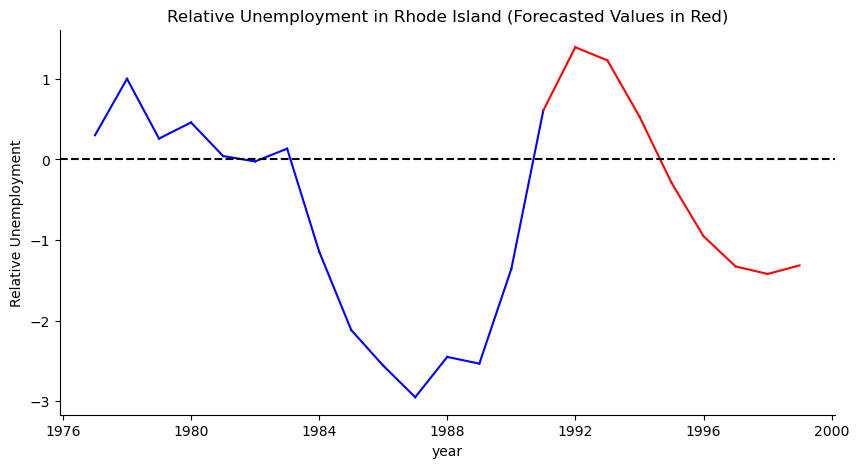

In [21]:
fig, ax = plt.subplots(figsize=(10,5)) 

# This approach to plotting connects the real data to the forecasted data and distinguishes by color.
for i in range(1, len(full_series)):
    if full_series['forecast'].iloc[i] == 1:
        color = 'red'  # Color for indicator 1
    else:
        color = 'blue'  # Color for indicator 0
     
    ax.plot([full_series.index[i-1],full_series.index[i]], [full_series['unemp'].iloc[i-1],full_series['unemp'].iloc[i]], color=color)

sns.despine(ax=ax)

plt.axhline(y=0, color='black', linestyle='--')

ax.set_title('Relative Unemployment in Rhode Island (Forecasted Values in Red)')
ax.set_ylabel('Relative Unemployment')
ax.set_xlabel('year')

plt.show()

## Practice

Let's try some more time series forecasting. Talk to your neighbor or let me know if you have questions.

1. Using pandas datareader, bring in the `'^SPX`' time series for S&P 500 daily prices from `'stooq'` from 2022-05-01 to 2023-01-01. Call the resulting dataframe `sp`. Sort the index.

2. Plot the time series from the column called 'Close' (the daily closing prices).

3. Let's set the frequency to business days using  the following line of code.
```python
sp = sp.asfreq("B")
```

This created a few missing values. Let's fill these missing values with the average of the values right before and after. This is called "linear interpolation." Here's the code.

In [24]:
sp = sp.asfreq('B')
sp['Close'] = sp['Close'].interpolate()
sp.loc['2022-05-26':'2022-06-01']

NameError: name 'sp' is not defined

4. Create a new dataframe that subsets the original dataframe to dates only on or before '2022-10-31'. Keep only the column 'Close' and the DatetimeIndex.

5. Fit an AR(20) process with the resulting time series using the argument `lags=20`.

6. We're going to use the model to forecast all the observations in our dataset after '2022-10-31'. How many such observations do we have to forecast?

7. Forecast this number of observations and plot the forecasted time series along with the actual time series (*including* the actual observations after '2022-10-31'). Give these two time series different colors and use a legend to distinguish the actual from the forecasted data.

## Pooling all states together

Let's return to the problem of state unemployment and focus our attention now on the same AR(2) process. However, to increase statistical power we will pool all states together and include state fixed effects. So, we will run the following:

$$ y_{s,t} = \alpha_0 + \alpha_1 y_{s,t-1} + \alpha_2 y_{s,t-2} + \eta_s + \epsilon_{s,t} $$

Where $s$ stands for state, $t$ stands for year, and $\eta_s$ represents the fixed effect for state $s$.

Let's use the `.shift()` function to create lagged variables of the unemployment rates by state.

In [ ]:
# Create lagged variables using .shift()
unemp_s.reset_index(inplace=True)
unemp_s['unemp_lag']=unemp_s.groupby('state')['unemp'].shift()
unemp_s['unemp_lag2']=unemp_s.groupby('state')['unemp'].shift(2)
unemp_s.head()

In [ ]:
res_ols = smf.ols('unemp ~ unemp_lag + unemp_lag2 + C(state)', data=unemp_s).fit()
print(res_ols.summary())

The parameters of interest are 1.0740 on `unemp_lag` and -0.3536 on `unemp_lag2`. These summarize how the current value depends on the previous two values.

\[Note: we could have also used the `tsa.AutoReg()` model to estimate this pooled AR(2) process with state fixed effects.\]

## Impulse Response

How do we interpret the results of the pooled AR(2) process? If we are less focused on forecasting a specific time series and more interested in understanding the general structure of the process, an impulse response function can be useful.

The idea is as follows. Imagine that state X's economy is in steady state and relative unemployment is stable. Now, imagine a positive shock to unemployment in state X in period t=0. What level of unemployment does the AR(2) process predict in state X in period t=1? What about in period t=2? t=10?

To see what happens, we can use the coefficient estimates and iterate over the AR(2) process, construcing predicted values for future relative unemployment levels.

In [ ]:
# Assign the lag coefficient estimates
a1 = res_ols.params['unemp_lag']
a2 = res_ols.params['unemp_lag2']
# Initialize the response in periods t=0 and t=1
response = [1, a1]
# Iterate over the process to period t=15
for i in range(2,15,1):
    response.append(a1*response[i-1]+a2*response[i-2])
# Plot the impulse response
fig, ax = plt.subplots(figsize=(10,5)) 
ax.plot(response, color='black') 
plt.axhline(y=0, color='black', linestyle='--')
ax.set_title('Impulse Response, AR(2) Process')
ax.set(xlabel='Years after shock')
sns.despine(ax=ax)

Nice. According to the model, after a shock, unemployment returns to normal after about 5 or 6 years.

It is worth noting that the `AR()` process can lead to very different and possibly complicated dynamics. The impulse response might converge to a value that is different from the original, cycle between values, or diverge.